# Notebook 23. Objective-Regime Timing, Transition, and Coastal-Impact Setup

This notebook takes the simplified objective regime labels from `Notebook 22` and asks the next Scott-guided questions:

- how often does a good offshore JPCZ precede coastal development?
- what lag does that transition usually have?
- which events stay offshore, stay coastal, or oscillate between the two?
- how can we attach a future coastal snow / precipitation impact table to these objective labels?

This notebook is intentionally lightweight:

- it uses the saved `Notebook 22` objective labels
- it builds broader spells/episodes from the merged 12 h catalog timing
- it treats coastal-impact data as an optional add-on table so the regime/timing work can proceed immediately


In [1]:
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/angelicasophyaramirez-blip/JPCZcatalogcolab.git"
BRANCH = os.environ.get("JPCZ_CATALOG_BRANCH", "codex/notebook16-pcolormesh")
REPO_DIR = "/content/JPCZcatalog"
FORCE_REFRESH_REPO = False
PERSIST_OUTPUTS_TO_DRIVE = True
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/JPCZcatalog_outputs"

if PERSIST_OUTPUTS_TO_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
    print("Persistent output dir:", DRIVE_OUTPUT_DIR)

os.chdir("/content")

def clone_repo_branch():
    proc = subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, REPO_DIR],
        text=True,
        capture_output=True,
    )
    print(proc.stdout)
    print(proc.stderr)
    if proc.returncode != 0:
        raise RuntimeError(f"git clone failed:\n{proc.stderr}")

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO_DIR}/requirements-colab.txt"],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR],
        check=True,
    )

def sync_repo_branch():
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "checkout", "-B", BRANCH, f"origin/{BRANCH}"], check=True)


if FORCE_REFRESH_REPO and os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print("Removed existing repo clone:", REPO_DIR)

if not os.path.exists(REPO_DIR):
    clone_repo_branch()
else:
    print("Using existing repo clone:", REPO_DIR)

try:
    sync_repo_branch()
except subprocess.CalledProcessError:
    print("Existing clone could not switch branches cleanly. Re-cloning target branch.")
    if os.path.exists(REPO_DIR):
        shutil.rmtree(REPO_DIR)
    clone_repo_branch()
    sync_repo_branch()

os.chdir(REPO_DIR)
src_dir = os.path.join(REPO_DIR, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

active_branch = subprocess.run(["git", "-C", REPO_DIR, "branch", "--show-current"], text=True, capture_output=True, check=True).stdout.strip()
print("Working directory:", os.getcwd())
print("Runtime repo branch:", active_branch)


Mounted at /content/drive
Persistent output dir: /content/drive/MyDrive/JPCZcatalog_outputs

Cloning into '/content/JPCZcatalog'...

Working directory: /content/JPCZcatalog
Runtime repo branch: codex/notebook16-pcolormesh


In [2]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from jpcz_catalog.analysis import add_japan_local_time_columns
from jpcz_catalog.objective_regimes import summarize_gap_sensitivity, summarize_objective_episodes

OBJECTIVE_EXPORT_DIR = Path("outputs/verification/objective_coastal_box_regimes")
VERIFICATION_DIR = Path("outputs/verification")
TIMING_EXPORT_DIR = Path("outputs/verification/objective_regime_timing_and_impact")
TIMING_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = Path("outputs/verification/objective_regime_timing_and_impact_plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

OBJECTIVE_EVENT_METRICS_PATH = OBJECTIVE_EXPORT_DIR / "objective_coastal_box_event_metrics.csv"
POSITION_INTENSITY_PATH = VERIFICATION_DIR / "jpcz_catalog_ndjf_merged_12h_position_intensity.csv"
COASTAL_IMPACT_INPUT_PATH = VERIFICATION_DIR / "coastal_impact_event_table.csv"

DEFAULT_GAP_HOURS = 36
GAP_HOURS_OPTIONS = (24, 36, 48)

EVENT_SEQUENCE_PATH = TIMING_EXPORT_DIR / f"objective_regime_event_sequences_gap{DEFAULT_GAP_HOURS:02d}h.csv"
EPISODE_SUMMARY_PATH = TIMING_EXPORT_DIR / f"objective_regime_episode_summary_gap{DEFAULT_GAP_HOURS:02d}h.csv"
GAP_SENSITIVITY_PATH = TIMING_EXPORT_DIR / "objective_regime_gap_sensitivity.csv"
TRANSITION_SUMMARY_PATH = TIMING_EXPORT_DIR / f"objective_regime_transition_summary_gap{DEFAULT_GAP_HOURS:02d}h.csv"
TRANSITION_EXAMPLES_PATH = TIMING_EXPORT_DIR / f"objective_regime_transition_examples_gap{DEFAULT_GAP_HOURS:02d}h.csv"
IMPACT_SUMMARY_PATH = TIMING_EXPORT_DIR / f"objective_regime_impact_summary_gap{DEFAULT_GAP_HOURS:02d}h.csv"
PLOT_INVENTORY_PATH = TIMING_EXPORT_DIR / "objective_regime_timing_plot_inventory.csv"

IMPACT_TABLE_HELP = """
Optional next-step impact table:
- save outputs/verification/coastal_impact_event_table.csv
- include either event_index or event_peak as the merge key
- add one or more coastal-impact columns such as:
  - coastal_precip_total_mm
  - coastal_snow_total_cm
  - station_heavy_snow_count
  - station_heavy_precip_count
  - impact_region_name
This notebook will merge that table automatically when it is present.
""".strip()


def maybe_copy_to_drive(path: Path, *, verbose: bool = True):
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return None
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if path.is_file():
        shutil.copy2(path, drive_path)
        if verbose:
            print("Copied to Drive:", drive_path)
        return drive_path
    return None


def restore_from_drive_cache(path: Path) -> bool:
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return False
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if not drive_path.exists():
        return False
    path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(drive_path, path)
    print("Restored from Drive cache:", drive_path)
    return True


In [3]:
paths_to_restore = [OBJECTIVE_EVENT_METRICS_PATH, POSITION_INTENSITY_PATH, COASTAL_IMPACT_INPUT_PATH]
for path in paths_to_restore:
    if not path.exists():
        restore_from_drive_cache(path)

if not OBJECTIVE_EVENT_METRICS_PATH.exists():
    raise RuntimeError("Run Notebook 22 first so the objective event-label table exists.")
if not POSITION_INTENSITY_PATH.exists():
    raise RuntimeError("Run Notebook 05 first so the merged 12 h position/intensity catalog exists.")

objective_df = pd.read_csv(
    OBJECTIVE_EVENT_METRICS_PATH,
    parse_dates=[column for column in ["event_start", "event_end", "event_peak", "event_peak_jst"] if column in pd.read_csv(OBJECTIVE_EVENT_METRICS_PATH, nrows=0).columns],
)
objective_df = add_japan_local_time_columns(objective_df)
if "event_index" not in objective_df.columns:
    objective_df["event_index"] = objective_df.index.astype(int)

position_df = pd.read_csv(
    POSITION_INTENSITY_PATH,
    parse_dates=["event_start", "event_end", "event_peak"],
)
position_df = add_japan_local_time_columns(position_df)
position_df["event_index"] = position_df.index.astype(int)

position_columns = [
    "event_index",
    "event_start",
    "event_end",
    "duration_hours",
    "episode_span_hours",
    "peak_max_convergence_1e5_s-1",
    "peak_max_convergence_lat",
    "peak_max_convergence_lon",
    "candidate_peak_convergence_percentile",
    "convergence_intensity_auto",
    "lat_position_group_auto",
    "lon_position_group_auto",
    "monsoon_type",
    "shinoda_class",
]
position_merge_df = position_df[[column for column in position_columns if column in position_df.columns]].copy()
event_df = objective_df.merge(position_merge_df, on="event_index", how="left", suffixes=("", "_position"))
for column in ["event_start", "event_end"]:
    fallback_column = f"{column}_position"
    if column in event_df.columns and fallback_column in event_df.columns:
        event_df[column] = event_df[column].fillna(event_df[fallback_column])
        event_df = event_df.drop(columns=[fallback_column])

impact_available = False
impact_merge_note = IMPACT_TABLE_HELP
impact_numeric_columns = []
impact_df = pd.DataFrame()
if COASTAL_IMPACT_INPUT_PATH.exists():
    impact_df = pd.read_csv(COASTAL_IMPACT_INPUT_PATH)
    if "event_index" in impact_df.columns:
        impact_df["event_index"] = impact_df["event_index"].astype(int)
        event_df = event_df.merge(impact_df, on="event_index", how="left", suffixes=("", "_impact"))
        impact_available = True
        impact_merge_note = f"Merged coastal-impact data from {COASTAL_IMPACT_INPUT_PATH.name} using event_index."
    elif "event_peak" in impact_df.columns:
        impact_df["event_peak"] = pd.to_datetime(impact_df["event_peak"])
        event_df = event_df.merge(impact_df, on="event_peak", how="left", suffixes=("", "_impact"))
        impact_available = True
        impact_merge_note = f"Merged coastal-impact data from {COASTAL_IMPACT_INPUT_PATH.name} using event_peak."
    else:
        impact_merge_note = (
            f"{COASTAL_IMPACT_INPUT_PATH.name} exists, but it must include either event_index or event_peak to merge.\n\n"
            f"{IMPACT_TABLE_HELP}"
        )

if "objective_regime_label" not in event_df.columns:
    raise RuntimeError("Notebook 22 event metrics must include objective_regime_label.")

gap_sensitivity_df = summarize_gap_sensitivity(event_df, gap_hours_options=GAP_HOURS_OPTIONS)
event_sequence_df, episode_summary_df = summarize_objective_episodes(event_df, gap_hours=DEFAULT_GAP_HOURS)

transition_summary_df = (
    episode_summary_df.groupby("objective_episode_regime_path", dropna=False)
    .agg(
        n_episodes=("objective_episode_id", "size"),
        median_event_count=("event_count", "median"),
        median_episode_duration_hours=("episode_duration_hours", "median"),
        median_offshore_to_coastal_lag_hours=("offshore_to_coastal_lag_hours", "median"),
    )
    .reset_index()
    .sort_values(["n_episodes", "objective_episode_regime_path"], ascending=[False, True])
)

transition_examples_df = (
    episode_summary_df.loc[episode_summary_df["offshore_precedes_coastal"]]
    .sort_values("offshore_to_coastal_lag_hours")
    .head(20)
    .copy()
)

if impact_available:
    merge_keys = {"event_index", "event_peak"}
    impact_numeric_columns = [
        column
        for column in impact_df.columns
        if column not in merge_keys and pd.api.types.is_numeric_dtype(event_df[column])
    ]
    if impact_numeric_columns:
        impact_summary_df = (
            event_sequence_df.groupby("objective_regime_label")[impact_numeric_columns]
            .agg(["median", "mean", "max"])
            .round(3)
        )
        impact_summary_df.columns = ["__".join([str(part) for part in column if part]) for column in impact_summary_df.columns.to_flat_index()]
        impact_summary_df = impact_summary_df.reset_index()
    else:
        impact_summary_df = pd.DataFrame()
else:
    impact_summary_df = pd.DataFrame()

for df, path in [
    (event_sequence_df, EVENT_SEQUENCE_PATH),
    (episode_summary_df, EPISODE_SUMMARY_PATH),
    (gap_sensitivity_df, GAP_SENSITIVITY_PATH),
    (transition_summary_df, TRANSITION_SUMMARY_PATH),
    (transition_examples_df, TRANSITION_EXAMPLES_PATH),
]:
    df.to_csv(path, index=False)
    maybe_copy_to_drive(path)
if impact_available and not impact_summary_df.empty:
    impact_summary_df.to_csv(IMPACT_SUMMARY_PATH, index=False)
    maybe_copy_to_drive(IMPACT_SUMMARY_PATH)

print("Notebook 23 objective timing setup")
print(f"- Active spell gap: {DEFAULT_GAP_HOURS} hours")
print(f"- Total objective-labeled events: {len(event_sequence_df)}")
print(f"- Total spells/episodes at {DEFAULT_GAP_HOURS} h: {len(episode_summary_df)}")
print("- Coastal-impact merge status:")
print(impact_merge_note)
print("\nGap sensitivity")
display(gap_sensitivity_df)
print("\nEpisode transition summary")
display(transition_summary_df)
if not transition_examples_df.empty:
    print("\nExample offshore-to-coastal episodes")
    display(transition_examples_df[[
        "objective_episode_id",
        "event_count",
        "objective_episode_regime_path",
        "collapsed_clear_sequence",
        "first_event_peak_jst",
        "last_event_peak_jst",
        "offshore_to_coastal_lag_hours",
    ]])
if impact_available and not impact_summary_df.empty:
    print("\nCoastal-impact summary by objective event label")
    display(impact_summary_df)


Restored from Drive cache: /content/drive/MyDrive/JPCZcatalog_outputs/objective_coastal_box_event_metrics.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_event_sequences_gap36h.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_episode_summary_gap36h.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_gap_sensitivity.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_transition_summary_gap36h.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_transition_examples_gap36h.csv
Notebook 23 objective timing setup
- Active spell gap: 36 hours
- Total objective-labeled events: 201
- Total spells/episodes at 36 h: 177
- Coastal-impact merge status:
Optional next-step impact table:
- save outputs/verification/coastal_impact_event_table.csv
- include either event_index or event_peak as the merge key
- add one or more coastal-impact columns such as

,gap_hours,episode_count,offshore_only_episodes,coastal_only_episodes,offshore_to_coastal_episodes,coastal_to_offshore_episodes,mixed_or_oscillating_episodes,weak_only_episodes,median_offshore_to_coastal_lag_hours
0,24.0,190,31,33,0,0,0,126,NaN
1,36.0,177,30,31,1,0,0,115,37.0
2,48.0,168,30,30,1,0,0,107,37.0



Episode transition summary


,objective_episode_regime_path,n_episodes,median_event_count,median_episode_duration_hours,median_offshore_to_coastal_lag_hours
3,weak_only,115,1.0,9.0,NaN
0,coastal_only,31,1.0,9.0,NaN
1,offshore_only,30,1.0,17.0,NaN
2,offshore_to_coastal,1,3.0,81.0,37.0



Example offshore-to-coastal episodes


,objective_episode_id,event_count,objective_episode_regime_path,collapsed_clear_sequence,first_event_peak_jst,last_event_peak_jst,offshore_to_coastal_lag_hours
133,obj_36h_134,3,offshore_to_coastal,offshore_jpcz_core -> coastal_interaction,2013-12-10 02:00:00,2013-12-13 06:00:00,37.0


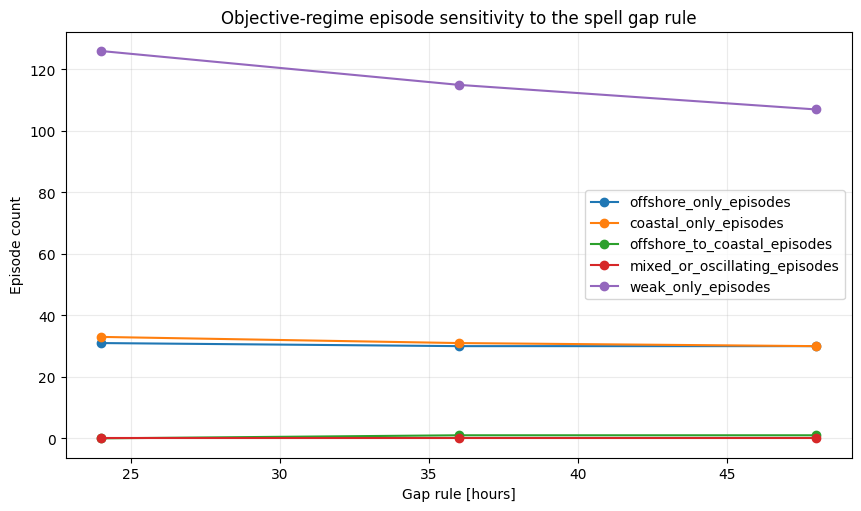

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_gap_sensitivity.png


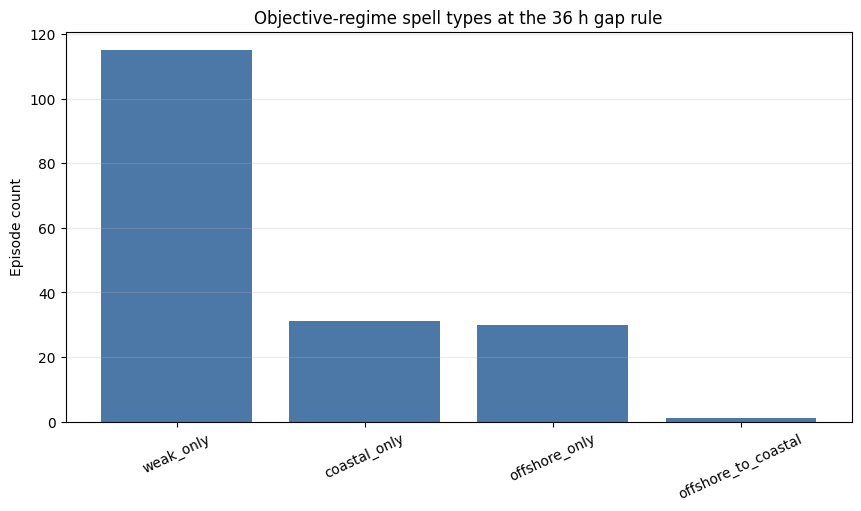

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_transition_counts_gap36h.png


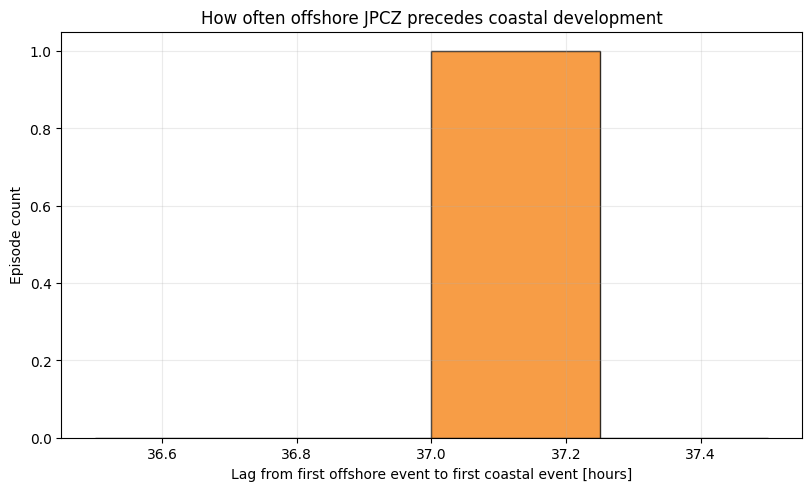

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_offshore_to_coastal_lag_gap36h.png
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_timing_plot_inventory.csv


PosixPath('/content/drive/MyDrive/JPCZcatalog_outputs/objective_regime_timing_plot_inventory.csv')

In [4]:
required_globals = [
    "gap_sensitivity_df",
    "episode_summary_df",
    "transition_summary_df",
    "transition_examples_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(f"Run the Notebook 23 timing-analysis cell first. Missing globals: {missing_globals}")

plot_inventory_rows = []

fig_gap, ax_gap = plt.subplots(figsize=(8.5, 5.0), constrained_layout=True)
gap_plot_df = gap_sensitivity_df.set_index("gap_hours")[[
    "offshore_only_episodes",
    "coastal_only_episodes",
    "offshore_to_coastal_episodes",
    "mixed_or_oscillating_episodes",
    "weak_only_episodes",
]]
gap_plot_df.plot(marker="o", ax=ax_gap)
ax_gap.set_xlabel("Gap rule [hours]")
ax_gap.set_ylabel("Episode count")
ax_gap.set_title("Objective-regime episode sensitivity to the spell gap rule")
ax_gap.grid(alpha=0.25)
gap_plot_path = PLOT_DIR / "objective_regime_gap_sensitivity.png"
fig_gap.savefig(gap_plot_path, dpi=170, bbox_inches="tight")
plt.show()
maybe_copy_to_drive(gap_plot_path)
plot_inventory_rows.append({"plot_name": "gap_sensitivity", "local_path": str(gap_plot_path)})

fig_transition, ax_transition = plt.subplots(figsize=(8.5, 5.0), constrained_layout=True)
transition_plot_df = transition_summary_df.sort_values("n_episodes", ascending=False)
ax_transition.bar(
    transition_plot_df["objective_episode_regime_path"],
    transition_plot_df["n_episodes"],
    color="#4c78a8",
)
ax_transition.set_ylabel("Episode count")
ax_transition.set_title(f"Objective-regime spell types at the {DEFAULT_GAP_HOURS} h gap rule")
ax_transition.grid(axis="y", alpha=0.25)
ax_transition.tick_params(axis="x", rotation=25)
transition_plot_path = PLOT_DIR / f"objective_regime_transition_counts_gap{DEFAULT_GAP_HOURS:02d}h.png"
fig_transition.savefig(transition_plot_path, dpi=170, bbox_inches="tight")
plt.show()
maybe_copy_to_drive(transition_plot_path)
plot_inventory_rows.append({"plot_name": "transition_counts", "local_path": str(transition_plot_path)})

lag_rows = episode_summary_df.loc[episode_summary_df["offshore_precedes_coastal"], "offshore_to_coastal_lag_hours"].dropna()
if not lag_rows.empty:
    fig_lag, ax_lag = plt.subplots(figsize=(8.0, 4.8), constrained_layout=True)
    ax_lag.hist(lag_rows.values, bins=min(12, max(4, len(lag_rows))), color="#f58518", edgecolor="black", alpha=0.8)
    ax_lag.set_xlabel("Lag from first offshore event to first coastal event [hours]")
    ax_lag.set_ylabel("Episode count")
    ax_lag.set_title("How often offshore JPCZ precedes coastal development")
    ax_lag.grid(alpha=0.25)
    lag_plot_path = PLOT_DIR / f"objective_regime_offshore_to_coastal_lag_gap{DEFAULT_GAP_HOURS:02d}h.png"
    fig_lag.savefig(lag_plot_path, dpi=170, bbox_inches="tight")
    plt.show()
    maybe_copy_to_drive(lag_plot_path)
    plot_inventory_rows.append({"plot_name": "offshore_to_coastal_lag_histogram", "local_path": str(lag_plot_path)})
else:
    print("No offshore-to-coastal episodes were identified with the current objective labels and gap rule.")

plot_inventory_df = pd.DataFrame(plot_inventory_rows)
plot_inventory_df.to_csv(PLOT_INVENTORY_PATH, index=False)
maybe_copy_to_drive(PLOT_INVENTORY_PATH)


In [5]:
required_globals = [
    "event_sequence_df",
    "episode_summary_df",
    "gap_sensitivity_df",
    "transition_summary_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(f"Run the Notebook 23 earlier cells before the summary cell. Missing globals: {missing_globals}")

print("Notebook 23 summary")
print("- This notebook converts the Notebook 22 objective event labels into broader spells/episodes.")
print("- It is the first notebook that directly answers how often offshore JPCZ precedes coastal development and what the lag looks like.")
print("- The spell logic uses merged-event timing plus a configurable gap rule; the current default is 36 h.")
print("- A coastal-impact table can be merged later without changing the objective regime labels.")
print("\nSaved outputs")
print(f"- Event-level sequences: {EVENT_SEQUENCE_PATH}")
print(f"- Episode summary: {EPISODE_SUMMARY_PATH}")
print(f"- Gap sensitivity: {GAP_SENSITIVITY_PATH}")
print(f"- Transition summary: {TRANSITION_SUMMARY_PATH}")
if COASTAL_IMPACT_INPUT_PATH.exists():
    print(f"- Coastal-impact input used: {COASTAL_IMPACT_INPUT_PATH}")
else:
    print(f"- Coastal-impact input still missing: {COASTAL_IMPACT_INPUT_PATH}")
    print(IMPACT_TABLE_HELP)


Notebook 23 summary
- This notebook converts the Notebook 22 objective event labels into broader spells/episodes.
- It is the first notebook that directly answers how often offshore JPCZ precedes coastal development and what the lag looks like.
- The spell logic uses merged-event timing plus a configurable gap rule; the current default is 36 h.
- A coastal-impact table can be merged later without changing the objective regime labels.

Saved outputs
- Event-level sequences: outputs/verification/objective_regime_timing_and_impact/objective_regime_event_sequences_gap36h.csv
- Episode summary: outputs/verification/objective_regime_timing_and_impact/objective_regime_episode_summary_gap36h.csv
- Gap sensitivity: outputs/verification/objective_regime_timing_and_impact/objective_regime_gap_sensitivity.csv
- Transition summary: outputs/verification/objective_regime_timing_and_impact/objective_regime_transition_summary_gap36h.csv
- Coastal-impact input still missing: outputs/verification/coastal